<a href="https://colab.research.google.com/github/salmanmfa2/data-science-2026/blob/main/Pertemuan4_Salman_MFA_240401010356.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


Step 1 : Load & Inspect Data

In [4]:
df = sns.load_dataset('iris')
print(f'Shape : {df.shape}')
print(f'Data Types : {df.dtypes}')
print(df.head())
print(df.describe().round(3))
print(df.isnull().sum())

Shape : (150, 5)
Data Types : sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300

Step 2 : Statistik Deskriptif Lengkap

In [7]:
for col_name in df.select_dtypes(include = 'number').columns:
  col = df[col_name]

  print(f'\n=== {col_name} ===')
  print(f' Mean : {col.mean():.3f}')
  print(f' Median : {col.median():.3f}')
  print(f' Std Dev : {col.std():.3f}')
  print(f' Skewness : {col.skew():.3f}')
  print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762
 Skewness : -0.103
 Kurtosis : -1.341


Step 3 : Analisis Distribusi (Histogram + KDE)

Text(0, 0.5, 'Frequency')

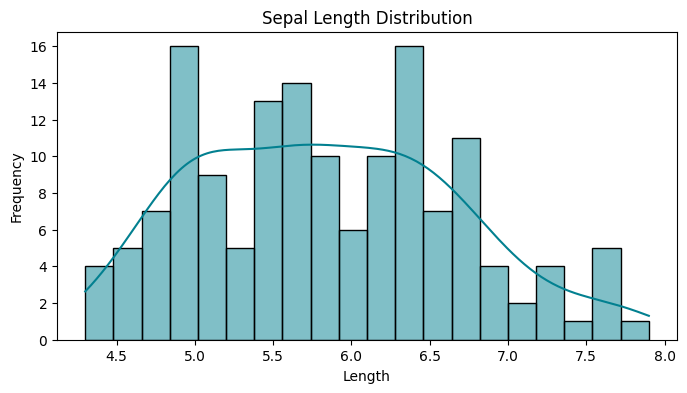

In [11]:
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(df['sepal_length'],kde=True,color='#028090', bins=20, ax = ax)
ax.set_title('Sepal Length Distribution')
ax.set_xlabel('Length')
ax.set_ylabel('Frequency')

Step 4 : Boxplot per Spesies

/tmp/ipykernel_390/3344209894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
/tmp/ipykernel_390/3344209894.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='species', y='petal_length',palette='Set2', inner='box', ax=axes[1])


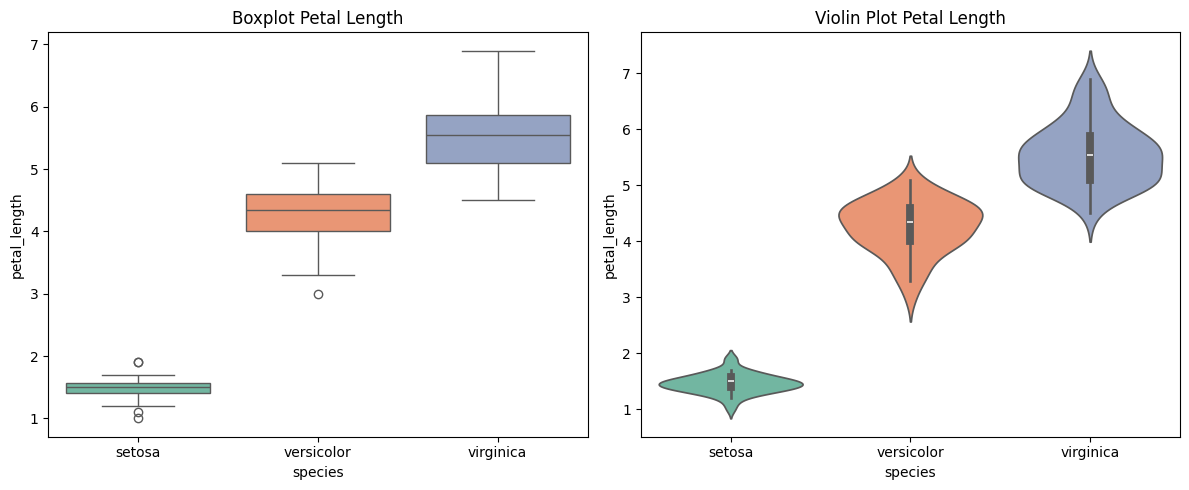

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='species', y='petal_length', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Petal Length')
sns.violinplot(data=df, x='species', y='petal_length',palette='Set2', inner='box', ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')
plt.tight_layout()
plt.show()

Step 5 : Matriks Korelasi Pearson

In [13]:
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))
import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963


Step 6 : Scatter Plot & Heatmap

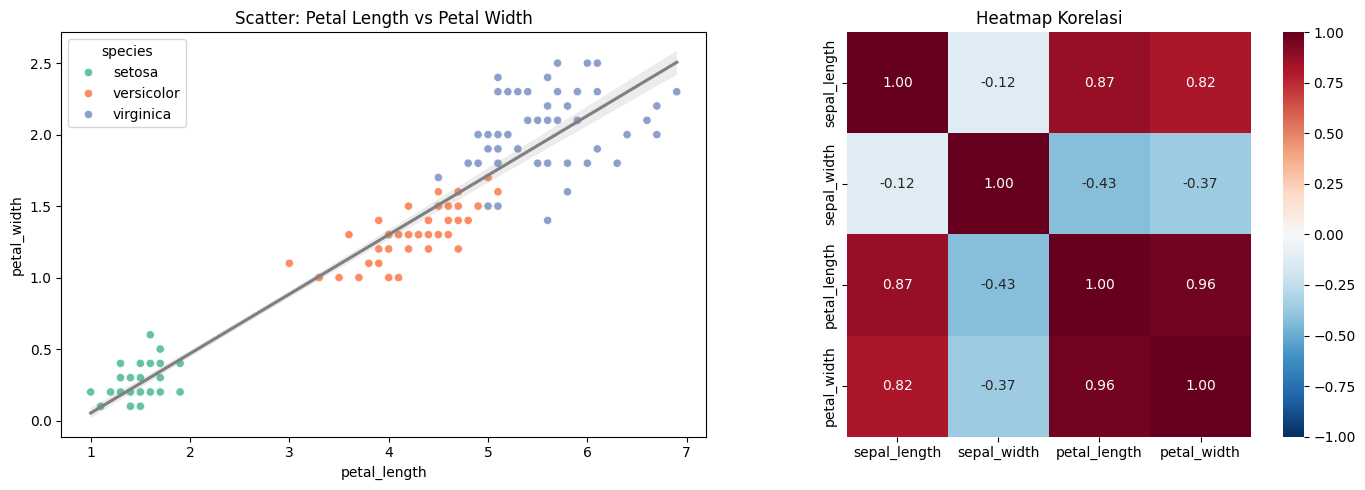

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()